In [ ]:
using Plots
using LinearAlgebra
using Colors

gr()

function rosenbrock_3d(x)
    return (1.0 - x[1])^2 + 100.0*(x[2] - x[1]^2)^2 + (1.0 - x[2])^2 + 100.0*(x[3] - x[2]^2)^2
end

function rastrigin_3d(x)
    n = length(x)
    return 10*n + sum(x[i]^2 - 10*cos(2*pi*x[i]) for i in 1:n)
end

function schwefel_3d(x)
    n = length(x)
    return 418.9829*n - sum(x[i]*sin(sqrt(abs(x[i]))) for i in 1:n)
end

function create_initial_simplex(x0, n, alpha=1.0)
    simplex = [copy(x0)]
    q = (sqrt(n+1) - 1) / (n * sqrt(2))
    p = q + 1 / sqrt(2)
    for i in 1:n
        x_new = copy(x0)
        for j in 1:n
            if j == i
                x_new[j] += alpha * p
            else
                x_new[j] += alpha * q
            end
        end
        push!(simplex, x_new)
    end
    return simplex
end

function simplex_method(f, x0, eps=1e-3, alpha=1.0, max_iterations=5000)
    n = length(x0)
    simplex = create_initial_simplex(x0, n, alpha)
    
    trajectory = [copy(x0)]
    all_simplexes = [copy(simplex)]
    
    iteration = 0
    
    while iteration < max_iterations
        iteration += 1
        
        vals = [f(p) for p in simplex]
        worst_idx = argmax(vals)
        best_idx = argmin(vals)
        
        centroid_all = sum(simplex) / length(simplex)
        max_distance = maximum([norm(p - centroid_all) for p in simplex])
        if max_distance < eps
            break
        end
        
        centroid = (sum(simplex) - simplex[worst_idx]) / (length(simplex) - 1)
        
        x_reflected = 2.0 .* centroid .- simplex[worst_idx]
        f_reflected = f(x_reflected)
        
        if f_reflected < vals[worst_idx]
            simplex[worst_idx] = x_reflected
            push!(trajectory, copy(x_reflected))
        else
            x_best = copy(simplex[best_idx])
            for i in 1:length(simplex)
                if i != best_idx
                    simplex[i] = x_best .+ 0.5 .* (simplex[i] .- x_best)
                end
            end
            push!(trajectory, copy(x_best))
        end
        
        push!(all_simplexes, copy(simplex))
    end
    
    best_index = argmin([f(p) for p in simplex])
    result = simplex[best_index]
    
    return result, trajectory, all_simplexes, iteration
end

function create_initial_simplex_nm(x0, n, alpha=0.05)
    simplex = [copy(x0)]
    for i in 1:n
        x_new = copy(x0)
        x_new[i] += alpha
        push!(simplex, x_new)
    end
    return simplex
end

function nelder_mead_method(f, x0, eps=1e-3, alpha=1.0, max_iterations=5000)
    n = length(x0)
    simplex = create_initial_simplex_nm(x0, n, 0.05)
    
    α_nm = 1.0
    β_nm = 2.0
    ρ_nm = 0.5
    δ_nm = 0.5
    
    trajectory = [copy(x0)]
    all_simplexes = [copy(simplex)]
    
    iteration = 0
    
    while iteration < max_iterations
        iteration += 1
        
        simplex = sort(simplex, by=f)
        
        best = simplex[1]
        worst = simplex[end]
        second_worst = simplex[end-1]
        
        centroid = sum(simplex[1:end-1]) / (length(simplex) - 1)
        max_distance = maximum([norm(p - centroid) for p in simplex])
        if max_distance < eps
            break
        end
        
        centroid = sum(simplex[1:end-1]) / (length(simplex) - 1)
        
        x_reflected = centroid .+ α_nm .* (centroid .- worst)
        f_reflected = f(x_reflected)
        f_best = f(best)
        f_second_worst = f(second_worst)
        f_worst = f(worst)
        
        if f_reflected < f_best
            x_expanded = centroid .+ β_nm .* (x_reflected .- centroid)
            f_expanded = f(x_expanded)
            
            if f_expanded < f_reflected
                simplex[end] = x_expanded
                push!(trajectory, copy(x_expanded))
            else
                simplex[end] = x_reflected
                push!(trajectory, copy(x_reflected))
            end
            
        elseif f_reflected < f_second_worst
            simplex[end] = x_reflected
            push!(trajectory, copy(x_reflected))
            
        else
            if f_reflected < f_worst
                x_contracted = centroid .+ ρ_nm .* (x_reflected .- centroid)
            else
                x_contracted = centroid .+ ρ_nm .* (worst .- centroid)
            end
            f_contracted = f(x_contracted)
            
            if f_contracted < min(f_reflected, f_worst)
                simplex[end] = x_contracted
                push!(trajectory, copy(x_contracted))
            else
                for i in 2:length(simplex)
                    simplex[i] = best .+ δ_nm .* (simplex[i] .- best)
                end
                push!(trajectory, copy(best))
            end
        end
        
        push!(all_simplexes, copy(simplex))
    end
    
    result = simplex[1]
    
    return result, trajectory, all_simplexes, iteration
end

function plot_tetrahedron!(plt, simplex, color, alpha_val, linewidth_val, label_str)
    if length(simplex) < 4
        return
    end
    edges = [
        (1, 2), (1, 3), (1, 4),
        (2, 3), (2, 4),
        (3, 4)
    ]
    for (i, (v1, v2)) in enumerate(edges)
        plot!(plt,
            [simplex[v1][1], simplex[v2][1]],
            [simplex[v1][2], simplex[v2][2]],
            [simplex[v1][3], simplex[v2][3]],
            linecolor=color,
            linewidth=linewidth_val,
            label=(i == 1 ? label_str : ""),
            alpha=alpha_val
        )
    end
end

function get_red_gradient_color(t)
    r = clamp(1.0 - 0.7 * t, 0.0, 1.0)
    g = clamp(0.7 - 0.7 * t, 0.0, 1.0)
    b = clamp(0.7 - 0.7 * t, 0.0, 1.0)
    return RGB(r, g, b)
end

function get_blue_gradient_color(t)
    r = clamp(0.7 - 0.7 * t, 0.0, 1.0)
    g = clamp(0.7 - 0.7 * t, 0.0, 1.0)
    b = clamp(1.0 - 0.7 * t, 0.0, 1.0)
    return RGB(r, g, b)
end

function plot_comparison_3d_tetrahedra(f, x0, result_simple, result_nm, 
                                       traj_simple, traj_nm, 
                                       simplexes_simple, simplexes_nm,
                                       title_str)
    plt1 = plot3d(legend=:topright, size=(600, 500), dpi=100, title="Простой симплекс")
    
    n_simple = length(simplexes_simple)
    for (idx, simplex) in enumerate(simplexes_simple)
        if length(simplex) >= 4
            t = (idx - 1) / max(n_simple - 1, 1)
            color = get_red_gradient_color(t)
            lbl = idx == 1 ? "Начало (светлый)" : (idx == n_simple ? "Конец (темный)" : "")
            plot_tetrahedron!(plt1, simplex, color, 0.7, 1.5, lbl)
        end
    end
    
    scatter3d!(plt1, [x0[1]], [x0[2]], [x0[3]], 
              color=:lime, markersize=6, label="Старт")
    scatter3d!(plt1, [result_simple[1]], [result_simple[2]], [result_simple[3]], 
              color=:black, markersize=6, markershape=:star5, label="Финиш")
    
    xlabel!(plt1, "x1"); ylabel!(plt1, "x2"); zlabel!(plt1, "x3")
    plot!(plt1, camera=(30, 30))
    
    plt2 = plot3d(legend=:topright, size=(600, 500), dpi=100, title="Нельдер-Мид")
    
    n_nm = length(simplexes_nm)
    for (idx, simplex) in enumerate(simplexes_nm)
        if length(simplex) >= 4
            t = (idx - 1) / max(n_nm - 1, 1)
            color = get_blue_gradient_color(t)
            lbl = idx == 1 ? "Начало (светлый)" : (idx == n_nm ? "Конец (темный)" : "")
            plot_tetrahedron!(plt2, simplex, color, 0.7, 1.5, lbl)
        end
    end
    
    scatter3d!(plt2, [x0[1]], [x0[2]], [x0[3]], 
              color=:lime, markersize=6, label="Старт")
    scatter3d!(plt2, [result_nm[1]], [result_nm[2]], [result_nm[3]], 
              color=:black, markersize=6, markershape=:star5, label="Финиш")
    
    xlabel!(plt2, "x1"); ylabel!(plt2, "x2"); zlabel!(plt2, "x3")
    plot!(plt2, camera=(30, 30))
    
    # --- Объединяем ---
    combined = plot(plt1, plt2, layout=(1, 2), size=(1200, 500),
                    plot_title=title_str)
    
    return combined
end

function compare_methods_3d(f, f_name, x0)
    println("\n" * "="^70)
    println("СРАВНЕНИЕ МЕТОДОВ для функции: $f_name (3D)")
    println("Начальная точка: $x0")
    println("="^70)
    
    result_simple, traj_simple, simplexes_simple, iter_simple = simplex_method(f, x0)
    result_nm, traj_nm, simplexes_nm, iter_nm = nelder_mead_method(f, x0)
    
    f_simple = f(result_simple)
    f_nm = f(result_nm)
    
    println("\n--- Метод простого симплекса ---")
    println("Результат: $result_simple")
    println("Значение функции: $f_simple")
    println("Количество итераций: $iter_simple")
    println("Количество тетраэдров: $(length(simplexes_simple))")
    println("Количество точек траектории: $(length(traj_simple))")
    
    println("\n--- Метод Нельдера-Мида ---")
    println("Результат: $result_nm")
    println("Значение функции: $f_nm")
    println("Количество итераций: $iter_nm")
    println("Количество тетраэдров: $(length(simplexes_nm))")
    println("Количество точек траектории: $(length(traj_nm))")
    
    println("Лучшее значение функции:")
    if f_simple < f_nm
        println("Простой симплекс: $f_simple (лучше на $(f_nm - f_simple))")
    elseif f_nm < f_simple
        println("Нельдер-Мид: $f_nm (лучше на $(f_simple - f_nm))")
    else
        println("  = Оба метода дали одинаковый результат: $f_simple")
    end

    
    title_3d = "Сравнение методов - $f_name (3D, тетраэдры)"
    plt_3d = plot_comparison_3d_tetrahedra(f, x0, result_simple, result_nm,
                                           traj_simple, traj_nm,
                                           simplexes_simple, simplexes_nm,
                                           title_3d)
    display(plt_3d)
    
    return result_simple, result_nm, traj_simple, traj_nm, plt_3d
end

compare_methods_3d (generic function with 1 method)


СРАВНЕНИЕ МЕТОДОВ для функции: Розенброк (3D)
Начальная точка: [1.5, 2.0, 1.0]

--- Метод простого симплекса ---
Результат: [1.09575724847025, 1.2011923920442706, 1.4443552918017761]
Значение функции: 0.04989632575304603
Количество итераций: 23
Количество тетраэдров: 23
Количество точек траектории: 23

--- Метод Нельдера-Мида ---
Результат: [0.9999383104281091, 0.99986947595142, 0.9997104775081536]
Значение функции: 1.0712870183845714e-7
Количество итераций: 104
Количество тетраэдров: 104
Количество точек траектории: 104
Лучшее значение функции:
Нельдер-Мид: 1.0712870183845714e-7 (лучше на 0.04989621862434419)


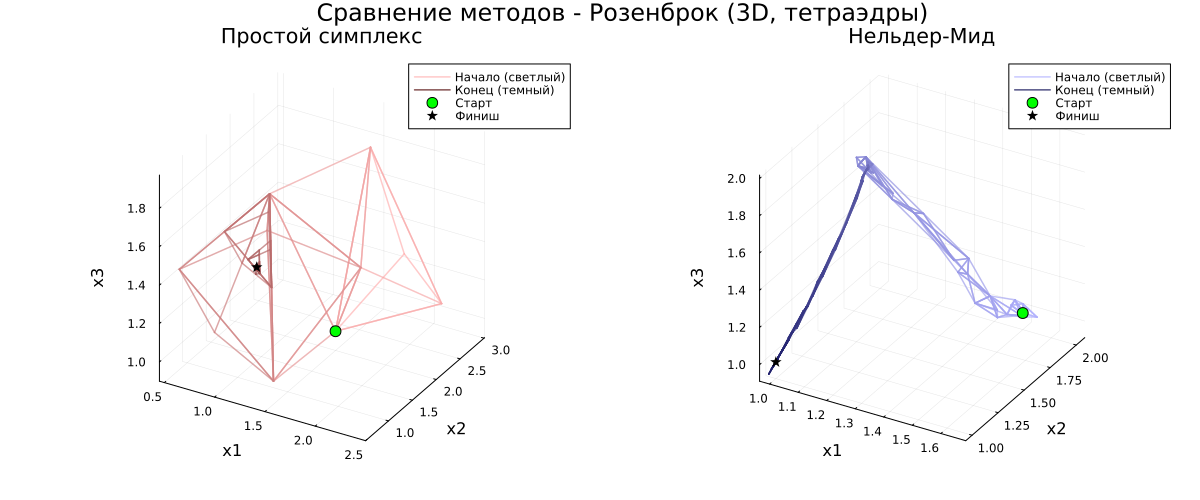

([1.09575724847025, 1.2011923920442706, 1.4443552918017761], [0.9999383104281091, 0.99986947595142, 0.9997104775081536], [[1.5, 2.0, 1.0], [2.0499719409228705, 1.3714606389452926, 1.5499719409228698], [1.0809737592968611, 1.5024063391650233, 1.7594850612744397], [1.351594873084305, 1.0135423916780284, 0.9301622932161431], [1.488360382202691, 0.5916062465255627, 1.8264128636089683], [0.5639807354663673, 0.7002426793004504, 1.4607348711434975], [0.5093391963623315, 1.552521360236772, 0.9405086201470856], [1.0809737592968611, 1.5024063391650233, 1.7594850612744397], [1.284667070749776, 1.047006292845293, 1.792948962441704], [1.216284316190583, 1.2579743654215259, 1.3448236772452913]  …  [1.0686066653872195, 1.19923066935073, 1.4443060356066704], [1.0974935293477297, 1.1958357808265148, 1.4557334728712163], [1.0911281133648263, 1.2100670322740066, 1.4546877259597402], [1.106268709952733, 1.2080210057080731, 1.4514140834542464], [1.0953565682677548, 1.2024285330945221, 1.4417295577088285], 

In [ ]:
# Тест 1: Розенброк (3D)
x0_rosenbrock_3d = [1.5, 2.0, 1.0]
result_r1_simple, result_r1_nm, traj_r1_simple, traj_r1_nm, plt_3d_r1 = 
    compare_methods_3d(rosenbrock_3d, "Розенброк", x0_rosenbrock_3d)



СРАВНЕНИЕ МЕТОДОВ для функции: Растригин (3D)
Начальная точка: [0.5, 0.5, 0.5]

--- Метод простого симплекса ---
Результат: [0.9951693212751214, 0.9950636520018601, 0.9948981900112256]
Значение функции: 2.984888884489589
Количество итераций: 24
Количество тетраэдров: 24
Количество точек траектории: 24

--- Метод Нельдера-Мида ---
Результат: [0.9945716878337612, 0.9947947889284054, -0.0002013784891388349]
Значение функции: 1.9899611727166118
Количество итераций: 47
Количество тетраэдров: 47
Количество точек траектории: 47
Лучшее значение функции:
Нельдер-Мид: 1.9899611727166118 (лучше на 0.9949277117729771)


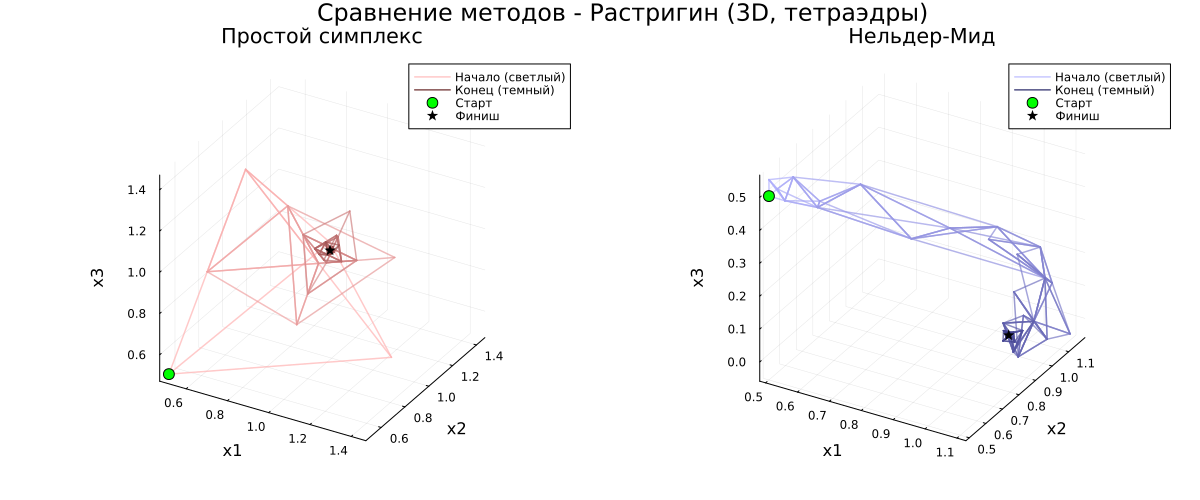

([0.9951693212751214, 0.9950636520018601, 0.9948981900112256], [0.9945716878337612, 0.9947947889284054, -0.0002013784891388349], [[0.5, 0.5, 0.5], [0.7357022603955158, 0.7357022603955158, 1.4428090415820631], [0.892837100659193, 0.8928371006591928, 0.657134840263677], [1.1940122111645743, 1.194012211164574, 0.9190262407031389], [1.0892556509887894, 0.7357022603955158, 1.0892556509887894], [0.9408505240730942, 1.0587016542708523, 0.8884722439852015], [1.005595898070628, 1.143088883301346, 1.1147173149204037], [0.9408505240730942, 1.0587016542708523, 0.8884722439852015], [1.019902928279821, 1.0068083582578478, 1.0693713039183856], [1.0186500527530273, 0.9018901367237668, 1.0014331180945066]  …  [1.0054828848062638, 1.001623219876948, 1.0137590482323595], [1.0052759432990006, 0.9860887608362483, 0.9866444717553904], [0.9947871647699305, 1.005332200453778, 0.9997103518758141], [0.9919473011019948, 0.9917654320739118, 0.9924979601036901], [0.9933672329359626, 0.9985488162638448, 0.996104155

In [ ]:
# Тест 2: Растригин (3D)
x0_rastrigin_3d = [0.5, 0.5, 0.5]
result_r2_simple, result_r2_nm, traj_r2_simple, traj_r2_nm, plt_3d_r2 = 
    compare_methods_3d(rastrigin_3d, "Растригин", x0_rastrigin_3d)



СРАВНЕНИЕ МЕТОДОВ для функции: Швефель (3D)
Начальная точка: [0.5, 0.5, 0.5]

--- Метод простого симплекса ---
Результат: [5.23941753063974, 5.23911351923728, 5.239710878496582]
Значение функции: 1245.1127951880965
Количество итераций: 48
Количество тетраэдров: 48
Количество точек траектории: 48

--- Метод Нельдера-Мида ---
Результат: [5.238897815877396, 5.239381520145577, 5.239485331260033]
Значение функции: 1245.112795165726
Количество итераций: 74
Количество тетраэдров: 74
Количество точек траектории: 74
Лучшее значение функции:
Нельдер-Мид: 1245.112795165726 (лучше на 2.237038643215783e-8)


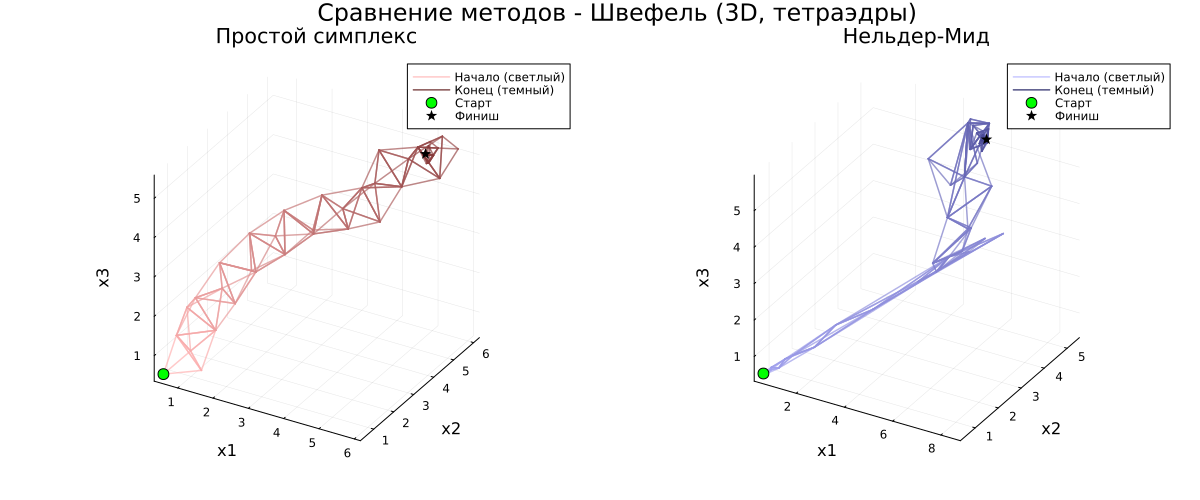

([5.23941753063974, 5.23911351923728, 5.239710878496582], [5.238897815877396, 5.239381520145577, 5.239485331260033], [[0.5, 0.5, 0.5], [1.442809041582063, 1.442809041582063, 1.442809041582063], [0.4999999999999998, 1.6785113019775788, 1.6785113019775788], [1.0499719409228696, 1.1285393610547083, 2.307050663032288], [1.259485061274439, 2.0975375426807177, 2.1761049628125573], [2.0015106958529145, 1.4340793282340796, 2.2721318096403604], [1.431169423784753, 1.663961779730941, 3.0607159154080747], [2.078138179685201, 2.3351797393757834, 2.698917795541706], [2.414393804940806, 1.5246096888798184, 3.1784053842475375], [1.9476235764209253, 2.248421477090283, 3.686560920491185]  …  [5.2260333183153955, 5.250820869428905, 5.234982750508492], [5.243266745605639, 5.233044679972398, 5.241151845977437], [5.243266745605639, 5.233044679972398, 5.241151845977437], [5.234650031960519, 5.241932774700652, 5.238067298242965], [5.242267585907971, 5.240501679770453, 5.239047091796932], [5.236419204133927, 

In [ ]:
# Тест 3: Швефель (3D)
x0_schwefel_3d = [0.5, 0.5, 0.5]
result_r3_simple, result_r3_nm, traj_r3_simple, traj_r3_nm, plt_3d_r3 = 
    compare_methods_3d(schwefel_3d, "Швефель", x0_schwefel_3d)
